## Is there a gender gap in agency within sports?

#### Author : Luna Gourrier
#### Date : May 2026

To be noted
- booknlp is a library that requires specific versions of other packages. If you have troubles running this code, please use 3.11 and the following versions of specific packages : torch==2.1.0, tensorflow==2.13.0, spacy==3.7.4, thinc==8.2.5, pydantic==1.10.13 (both spacy dependencies), transformers==4.38.0.
- part of this code was generated thanks to IA (Claude)

## Introduction

In order to reduce gender inequalities, it's important to understand them. Therefore, The goal of this project is to analyze the difference of agentivity between men and women in sports. In order to do so, wikipedia biographies were scrapped thanks to wikipedia API. Four sports were selected 

To reduce inequalities, it is important to understand them. This project was designed with that in mind. The goal is to examine the difference in agency between men and women in sports. To address this question, Wikipedia biographies of British male and female athletes were scraped using the Wikipedia API. Only one nationality was selected to avoid uncontrolled bias. Among these biographies, four sports are represented: rugby, soccer, figure skating, and gymnastics. These sports themselves fall into two categories: historically male-dominated sports (soccer and rugby) and historically female-dominated sports (figure skating and gymnastics). The analysis therefore focuses on the difference in agency between genders and the relationship between this difference in agency and these different types of sports. 

The dataset contains the names of the athletes in the ‘Name’ column, their biographies in the ‘Biography’ column, their sport and gender in the ‘Sport_Gender’ column, and their nationality in the ‘Nationality’ category.
To have a look at the scraping code, please refer to the file titled ‘CollecteDonneesAnglais.ipynb’.

## 1. Library import

In [1]:
import pandas as pd
import tempfile
from booknlp.booknlp import BookNLP
import re
import os
import sys
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
import seaborn as sns
import numpy as np

c:\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


using device cpu


In [2]:
# Forcing UTF-8 everywhere to be able to read correctly biographies later
os.environ["PYTHONUTF8"] = "1"
os.environ["PYTHONIOENCODING"] = "utf-8"
os.environ["BOOKNLP_CACHE"] = r"C:\booknlp_cache" # To replace with your path
os.environ["HF_HOME"] = r"C:\hf_cache" # To replace with your path

In [3]:
df = pd.read_csv('english_athletes_1000_limit.csv')
df

,Name,Biography,Sport_Gender,Nationality
0,Arthur Aaron (footballer),Arthur Frederick Aaron (21 September 1885 – 10...,Football_Men,English
1,Max Aarons,Maximillian James Aarons (born 4 January 2000)...,Football_Men,English
2,Rolando Aarons,Rolando Aarons (born 16 November 1995) is a pr...,Football_Men,English
3,Thelo Aasgaard,"Thelonious ""Thelo"" Gerard Aasgaard (born 2 May...",Football_Men,English
4,Godwin Abadaki,Godwin Olorunfemi Ebenmosi Abadaki (born 12 Oc...,Football_Men,English
...,...,...,...,...
3083,Danielle Waterman,"Danielle Sian ""Nolli"" Waterman (born 20 Januar...",Rugby_Women,English
3084,Bo Westcombe-Evans,Boudica Willow Westcombe-Evans (born 18 August...,Rugby_Women,English
3085,Kay Wilson,Kay Wilson (born 19 September 1991) is an Engl...,Rugby_Women,English
3086,Ella Wyrwas,Ella Maria Wyrwas (born 7 March 1999) is an En...,Rugby_Women,English


## 2. Getting the data

In [ ]:
# Creating a function to initiate the model's parameters

model_path = r"C:\booknlp_models"
def init_booknlp():
    model_params = {
        "pipeline": "entity,quote,supersense,event,coref",
        "model": "big",
        "model_path": model_path # To replace with your path
    }
    return BookNLP("en", model_params)

In [5]:
# Creating the function that extracts the number of verbs per biography

def count_subject_verbs(name, biography, booknlp_model, output_dir="booknlp_output"):
    os.makedirs(output_dir, exist_ok=True)

    # Cleaning texts to make a correct analysis by removing and normalizing characters that could disrupt NLP analysis
    biography_clean = biography
    biography_clean = re.sub(r'\[.*?\]', '', biography_clean)
    biography_clean = re.sub(r'/[^/]+/', '', biography_clean)
    biography_clean = re.sub(r'\w+:\s*;', '', biography_clean)
    biography_clean = re.sub(r'\w+:\s+[^:]+:', ' ', biography_clean)
    biography_clean = re.sub(r'\s*==.*?==\s*', ' ', biography_clean)
    biography_clean = re.sub(r'\d{1,2}\s+\w+\s+\d{4}\s*[–-]\s*\d{1,2}\s+\w+\s+\d{4}', '', biography_clean)
    biography_clean = re.sub(r'\d{4}\s*[–-]\s*(\d{4}|after\s*\d{4}|before\s*\d{4})', '', biography_clean)
    biography_clean = re.sub(r'\d{4}\s*[–-]\s*\w+', '', biography_clean)
    biography_clean = re.sub(r'\d{4}/\d{4}', '', biography_clean)
    biography_clean = re.sub(r'née\s+\w+', '', biography_clean)
    biography_clean = biography_clean.replace(";", "")
    biography_clean = biography_clean.encode("cp1252", errors="ignore").decode("cp1252")
    biography_clean = re.sub(r'^(Log in|Sign in|Login)[\s\n]+', '', biography_clean, flags=re.IGNORECASE)
    biography_clean = biography_clean.replace("(", "").replace(")", "")


    # Writing the cleaned text to a temporary file and process it with BookNLP
    with tempfile.NamedTemporaryFile(mode="w", suffix=".txt",
                                     delete=False, encoding="utf-8") as f:
        f.write(biography_clean)
        tmp_path = f.name

    book_id = "bio"

    try:
        booknlp_model.process(tmp_path, output_dir, book_id)
    finally:
        os.remove(tmp_path)

    # Loading the .entities file and find the coreference cluster (COREF id) that corresponds to the athlete
    entities_path = os.path.join(output_dir, f"{book_id}.entities")
    entities_df = pd.read_csv(entities_path, sep="\t", quoting=3)  # quoting=3 prevents pandas from misinterpreting quotes inside the file

    # Cleaning the athlete's name
    name_clean = re.sub(r'\(.*?\)', '', name).strip()
    name_clean = re.sub(r'\b(Sr|Jr|Sr\.|Jr\.)\b', '', name_clean).strip()
    last_name = name_clean.split()[-1].lower()

    # Normalize hyphens in entity text for better matching
    entities_text_normalized = entities_df["text"].str.lower().str.replace(" - ", "-", regex=False)

    # Searching for the athlete by last name first
    match = entities_df[
        entities_text_normalized.str.contains(last_name, na=False, regex=False)
    ]

    # Searching by full name if last name not found
    if match.empty:
        full_name = name_clean.lower()
        match = entities_df[
            entities_text_normalized.str.contains(full_name, na=False, regex=False)
        ]

    # Search by first name if full name not found
    if match.empty:
        first_name = name_clean.split()[0].lower()
        match = entities_df[
            entities_text_normalized.str.contains(first_name, na=False, regex=False)
        ]

    # If no mention found, return empty results
    if match.empty:
        return {"verb_count": 0, "verbs": [], "coref_id": None,
                "active_count": 0, "passive_count": 0,
                "active_verbs": [], "passive_verbs": [],
                "warning": f"Aucune mention trouvée pour '{name}'"}
        
    # Select the most frequent COREF id among matched mentions
    coref_id = match["COREF"].value_counts().idxmax()

    # Collecting all token ids that belong to any mention of the athlete
    person_mentions = entities_df[entities_df["COREF"] == coref_id]
    person_token_ids = set()
    for _, row in person_mentions.iterrows():
        for tok_id in range(int(row["start_token"]), int(row["end_token"]) + 1):
            person_token_ids.add(tok_id)

    # Loading the .tokens file and find verbs for which the athlete is the subject           
    tokens_path = os.path.join(output_dir, f"{book_id}.tokens")
    tokens_df = pd.read_csv(tokens_path, sep="\t", quoting=3)
    
    # Find tokens that belong to the athlete and are syntactic subjects
    subject_relations = {"nsubj", "nsubjpass"}
    subject_tokens = tokens_df[
        (tokens_df["token_ID_within_document"].isin(person_token_ids)) &
        (tokens_df["dependency_relation"].isin(subject_relations))
    ]

    # Separating active subjects (nsubj) from passive subjects (nsubjpass) and retrieve the ids of their head verbs  
    # int() conversion is necessary because syntactic_head_ID is stored as string
    active_head_ids = [int(x) for x in subject_tokens[subject_tokens["dependency_relation"] == "nsubj"]["syntactic_head_ID"].tolist()]
    passive_head_ids = [int(x) for x in subject_tokens[subject_tokens["dependency_relation"] == "nsubjpass"]["syntactic_head_ID"].tolist()]

    # Handling csubj question : if a verb head has dependency relation "csubj", it means the athlete's name is used as a clausal subject
    # We climb one level up to reach the actual main verb.
    expanded_active_ids = []
    for hid in active_head_ids:
        expanded_active_ids.append(hid)
        head_row = tokens_df[tokens_df["token_ID_within_document"] == hid]
        if not head_row.empty and head_row.iloc[0]["dependency_relation"] == "csubj":
            expanded_active_ids.append(int(head_row.iloc[0]["syntactic_head_ID"]))
    active_head_ids = expanded_active_ids

    expanded_passive_ids = []
    for hid in passive_head_ids:
        expanded_passive_ids.append(hid)
        head_row = tokens_df[tokens_df["token_ID_within_document"] == hid]
        if not head_row.empty and head_row.iloc[0]["dependency_relation"] == "csubj":
            expanded_passive_ids.append(int(head_row.iloc[0]["syntactic_head_ID"]))
    passive_head_ids = expanded_passive_ids

    # Handling who dependency question
    who_tokens = tokens_df[
        (tokens_df["word"].str.lower().isin(["who", "which"])) &
        (tokens_df["dependency_relation"].isin({"nsubj", "nsubjpass"}))
    ]
    for _, who_tok in who_tokens.iterrows():
        who_id = int(who_tok["token_ID_within_document"])
        who_head_id = int(who_tok["syntactic_head_ID"])
        prev_token_id = who_id - 1
        if prev_token_id in person_token_ids:
            if who_tok["dependency_relation"] == "nsubj":
                active_head_ids.append(who_head_id)
            else:
                passive_head_ids.append(who_head_id)

    # Handling coordinated verbs question
    active_conj = tokens_df[
        (tokens_df["syntactic_head_ID"].isin(active_head_ids)) &
        (tokens_df["dependency_relation"] == "conj") &
        (tokens_df["POS_tag"] == "VERB")
    ]["token_ID_within_document"].tolist()

    passive_conj = tokens_df[
        (tokens_df["syntactic_head_ID"].isin(passive_head_ids)) &
        (tokens_df["dependency_relation"] == "conj") &
        (tokens_df["POS_tag"] == "VERB")
    ]["token_ID_within_document"].tolist()

    # Retreiving verb lemmas and returning results
    active_verbs = tokens_df[tokens_df["token_ID_within_document"].isin(active_head_ids + active_conj)]["lemma"].tolist()
    passive_verbs = tokens_df[tokens_df["token_ID_within_document"].isin(passive_head_ids + passive_conj)]["lemma"].tolist()

    verbs = active_verbs + passive_verbs

    return {
        "verb_count": len(verbs),
        "verbs": verbs,
        "active_count": len(active_verbs),
        "passive_count": len(passive_verbs),
        "active_verbs": active_verbs,
        "passive_verbs": passive_verbs,
        "coref_id": coref_id
    }

In [6]:
def process_dataset(df, name_col, bio_col, test_only=False, output_dir="booknlp_output", save_path=None):
    df_processed = df.copy()

    # Creating a condition to test only the first line
    if test_only:      
        df_processed = df_processed.iloc[:1].copy()
        print(f"Mode test — traitement de : {df_processed[name_col].iloc[0]}")

    booknlp_model = init_booknlp()

    # Initializing new columns
    for col in ["verb_count", "verbs", "active_count", "passive_count", "active_verbs", "passive_verbs"]:
        if col not in df_processed.columns:
            df_processed[col] = None

    for i, row in df_processed.iterrows():
        # Cheking line has not already been analyzed
        if pd.notna(df_processed.at[i, "verb_count"]):
            print(f"[{i+1}] Déjà traité : {row[name_col]}")
            continue

        print(f"[{i+1}/{len(df_processed)}] Traitement de : {row[name_col]}")

        try:
            result = count_subject_verbs(row[name_col], row[bio_col], booknlp_model, output_dir=output_dir)
        except Exception as e:
            print(f"  ERREUR : {e}")
            result = {
                "verb_count": -1,
                "verbs": [],
                "active_count": -1,
                "passive_count": -1,
                "active_verbs": [],
                "passive_verbs": [],
                "coref_id": None
            }

        # Adding results to the dataset
        df_processed.at[i, "verb_count"]    = result["verb_count"]
        df_processed.at[i, "verbs"]         = str(result["verbs"])
        df_processed.at[i, "active_count"]  = result["active_count"]
        df_processed.at[i, "passive_count"] = result["passive_count"]
        df_processed.at[i, "active_verbs"]  = str(result["active_verbs"])
        df_processed.at[i, "passive_verbs"] = str(result["passive_verbs"])

        # Saving temporary the results only if a path was given
        if save_path and (i + 1) % 10 == 0:
            df_processed.to_csv(save_path, index=False)
            print(f"  Sauvegarde intermédiaire à la ligne {i+1}")

    # Final saving if asked
    if save_path:
        df_processed.to_csv(save_path, index=False)
        print("Terminé ! Résultats sauvegardés dans", save_path)
    else:
        print("Terminé ! Le DataFrame a été mis à jour avec succès.")

    return df_processed

In [7]:
# Testing the functions on the first line of the dataset

df_test = process_dataset(
    df=df, 
    name_col="Name",
    bio_col="Biography",
    test_only=True,
    output_dir=r"C:\booknlp_output",
    save_path=None # To replace with a path if you want to save the result
)
df_test

Mode test — traitement de : Arthur Aaron (footballer)
{'pipeline': 'entity,quote,supersense,event,coref', 'model': 'big', 'model_path': 'C:\\booknlp_models'}


c:\Python311\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


--- startup: 8.854 seconds ---
[1/1] Traitement de : Arthur Aaron (footballer)
--- spacy: 0.045 seconds ---
--- entities: 0.497 seconds ---
--- quotes: 0.000 seconds ---
--- attribution: 0.000 seconds ---
--- name coref: 0.002 seconds ---
--- coref: 1.766 seconds ---
--- TOTAL (excl. startup): 2.358 seconds ---, 110 words
Terminé ! Le DataFrame a été mis à jour avec succès.


,Name,Biography,Sport_Gender,Nationality,verb_count,verbs,active_count,passive_count,active_verbs,passive_verbs
0,Arthur Aaron (footballer),Arthur Frederick Aaron (21 September 1885 – 10...,Football_Men,English,8,"['be', 'be', 'become', 'marry', 'change', 'die...",6,2,"['be', 'be', 'become', 'marry', 'change', 'die']","['bear', 'baptise']"


In [8]:
# Getting all results

df_full = process_dataset(
    df=df, 
    name_col="Name",
    bio_col="Biography",
    test_only=False,
    output_dir=r"C:\booknlp_output", # To replace if your path is different
    save_path= None) # To replace with your path if you want to save it as safety

{'pipeline': 'entity,quote,supersense,event,coref', 'model': 'big', 'model_path': 'C:\\booknlp_models'}


c:\Python311\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


--- startup: 6.663 seconds ---
[1/3088] Traitement de : Arthur Aaron (footballer)
--- spacy: 0.031 seconds ---
--- entities: 0.336 seconds ---
--- quotes: 0.000 seconds ---
--- attribution: 0.000 seconds ---
--- name coref: 0.002 seconds ---
--- coref: 1.830 seconds ---
--- TOTAL (excl. startup): 2.232 seconds ---, 110 words
[2/3088] Traitement de : Max Aarons
--- spacy: 0.030 seconds ---
--- entities: 0.436 seconds ---
--- quotes: 0.000 seconds ---
--- attribution: 0.000 seconds ---
--- name coref: 0.000 seconds ---
--- coref: 2.151 seconds ---
--- TOTAL (excl. startup): 2.666 seconds ---, 194 words
[3/3088] Traitement de : Rolando Aarons
--- spacy: 0.016 seconds ---
--- entities: 0.477 seconds ---
--- quotes: 0.000 seconds ---
--- attribution: 0.000 seconds ---
--- name coref: 0.000 seconds ---
--- coref: 2.449 seconds ---
--- TOTAL (excl. startup): 2.976 seconds ---, 73 words
[4/3088] Traitement de : Thelo Aasgaard
--- spacy: 0.006 seconds ---
--- entities: 0.208 seconds ---
--- quo

In [9]:
df_full

,Name,Biography,Sport_Gender,Nationality,verb_count,verbs,active_count,passive_count,active_verbs,passive_verbs
0,Arthur Aaron (footballer),Arthur Frederick Aaron (21 September 1885 – 10...,Football_Men,English,8,"['be', 'be', 'become', 'marry', 'change', 'die...",6,2,"['be', 'be', 'become', 'marry', 'change', 'die']","['bear', 'baptise']"
1,Max Aarons,Maximillian James Aarons (born 4 January 2000)...,Football_Men,English,9,"['bear', 'join', 'go', 'become', 'join', 'prom...",5,4,"['bear', 'join', 'go', 'become', 'join']","['promote', 'relegate', 'send', 'join']"
2,Rolando Aarons,Rolando Aarons (born 16 November 1995) is a pr...,Football_Men,English,4,"['bear', 'be', 'represent', 'have']",4,0,"['bear', 'be', 'represent', 'have']",[]
3,Thelo Aasgaard,"Thelonious ""Thelo"" Gerard Aasgaard (born 2 May...",Football_Men,English,1,['bear'],1,0,['bear'],[]
4,Godwin Abadaki,Godwin Olorunfemi Ebenmosi Abadaki (born 12 Oc...,Football_Men,English,3,"['bear', 'play', 'loan']",3,0,"['bear', 'play', 'loan']",[]
...,...,...,...,...,...,...,...,...,...,...
3083,Danielle Waterman,"Danielle Sian ""Nolli"" Waterman (born 20 Januar...",Rugby_Women,English,2,"['bear', 'seven']",2,0,"['bear', 'seven']",[]
3084,Bo Westcombe-Evans,Boudica Willow Westcombe-Evans (born 18 August...,Rugby_Women,English,1,['bear'],1,0,['bear'],[]
3085,Kay Wilson,Kay Wilson (born 19 September 1991) is an Engl...,Rugby_Women,English,2,"['bear', 'include']",1,1,['bear'],['include']
3086,Ella Wyrwas,Ella Maria Wyrwas (born 7 March 1999) is an En...,Rugby_Women,English,2,"['be', 'bear']",1,1,['be'],['bear']


In [10]:
# Checking if there are mistakes in the dataset 

# Lines with 0 verbs
zero_verbs = df_full[df_full["verb_count"] == 0]
print(f"Lignes avec 0 verbe : {len(zero_verbs)} / {len(df_full)}")

# Lines with an error (number of verbs < 0)
errors = df_full[df_full["verb_count"] == -1]
print(f"Lignes avec erreur : {len(errors)} / {len(df_full)}")

# Printing some examples of lines with 0 verbs
print("\nExemples de lignes avec 0 verbe :")
print(zero_verbs[["Name", "Biography"]].head(10).to_string())

Lignes avec 0 verbe : 16 / 3088
Lignes avec erreur : 3 / 3088

Exemples de lignes avec 0 verbe :
                            Name                                                                                                                                                                                                                                                                                                       Biography
500           Ethan Amundsen-Day                                                                                                                  Ethan Amundsen-Day (born 9 May 2005) is a professional footballer who plays as a centre-back for Eliteserien club HamKam. Born in England, he represented Norway at youth international level.
812            Benny Ashley-Seal                                                                                                                                        Bernard Patrick Ashley-Seal (born 21 November 1998) is an Eng

Those problems couldn't be solved so it was decided to delete those lines from the dataset. The analysis could have been done manually but the human bias would have been too strong. Indeed, the analysis done with booknlp and spicy is probably unperfect but a handmade analysis would have get non error so there woud have been a difference between lines treated by hand and by computer.

## 3. Analysis

To analyze the results, the first step is to create ratios. Indeed, biographies length vary so this is a bias to be taken into account. 

In [11]:
# Deleting lines with errors

df_full = df_full[df_full['verb_count']>0]
df_full = df_full.reset_index(drop=True)

In [12]:
# Creating ratio columns for every type of verb to avoid the bias of the length of the text

for i in range(len(df_full)):
    df_full.loc[i, 'active_count_len_ratio']= (df_full.loc[i, 'active_count']) / (len(df_full.loc[i, 'Biography'].split()))
    df_full.loc[i, 'passive_count_len_ratio'] = df_full.loc[i, 'passive_count'] / len(df_full.loc[i, 'Biography'].split())
    df_full.loc[i, 'verb_len_ratio'] = df_full.loc[i, 'verb_count'] / len(df_full.loc[i, 'Biography'].split()) 

In [13]:
df_full

,Name,Biography,Sport_Gender,Nationality,verb_count,verbs,active_count,passive_count,active_verbs,passive_verbs,active_count_len_ratio,passive_count_len_ratio,verb_len_ratio
0,Arthur Aaron (footballer),Arthur Frederick Aaron (21 September 1885 – 10...,Football_Men,English,8,"['be', 'be', 'become', 'marry', 'change', 'die...",6,2,"['be', 'be', 'become', 'marry', 'change', 'die']","['bear', 'baptise']",0.058824,0.019608,0.078431
1,Max Aarons,Maximillian James Aarons (born 4 January 2000)...,Football_Men,English,9,"['bear', 'join', 'go', 'become', 'join', 'prom...",5,4,"['bear', 'join', 'go', 'become', 'join']","['promote', 'relegate', 'send', 'join']",0.028902,0.023121,0.052023
2,Rolando Aarons,Rolando Aarons (born 16 November 1995) is a pr...,Football_Men,English,4,"['bear', 'be', 'represent', 'have']",4,0,"['bear', 'be', 'represent', 'have']",[],0.063492,0.000000,0.063492
3,Thelo Aasgaard,"Thelonious ""Thelo"" Gerard Aasgaard (born 2 May...",Football_Men,English,1,['bear'],1,0,['bear'],[],0.032258,0.000000,0.032258
4,Godwin Abadaki,Godwin Olorunfemi Ebenmosi Abadaki (born 12 Oc...,Football_Men,English,3,"['bear', 'play', 'loan']",3,0,"['bear', 'play', 'loan']",[],0.073171,0.000000,0.073171
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3064,Danielle Waterman,"Danielle Sian ""Nolli"" Waterman (born 20 Januar...",Rugby_Women,English,2,"['bear', 'seven']",2,0,"['bear', 'seven']",[],0.036364,0.000000,0.036364
3065,Bo Westcombe-Evans,Boudica Willow Westcombe-Evans (born 18 August...,Rugby_Women,English,1,['bear'],1,0,['bear'],[],0.034483,0.000000,0.034483
3066,Kay Wilson,Kay Wilson (born 19 September 1991) is an Engl...,Rugby_Women,English,2,"['bear', 'include']",1,1,['bear'],['include'],0.038462,0.038462,0.076923
3067,Ella Wyrwas,Ella Maria Wyrwas (born 7 March 1999) is an En...,Rugby_Women,English,2,"['be', 'bear']",1,1,['be'],['bear'],0.028571,0.028571,0.057143


Now, all data are available to make the analysis.

## 3.1 Analyze per gender

### 3.1.2 Graphical display

In [14]:
df_full['Gender'] = df_full['Sport_Gender'].str.rsplit('_', n=1).str[-1] # creating a column only with the gender of the athlete

([<matplotlib.axis.XTick at 0x1cf4ba41410>,
 [Text(0, 0, 'Men'), Text(1, 0, 'Women')])

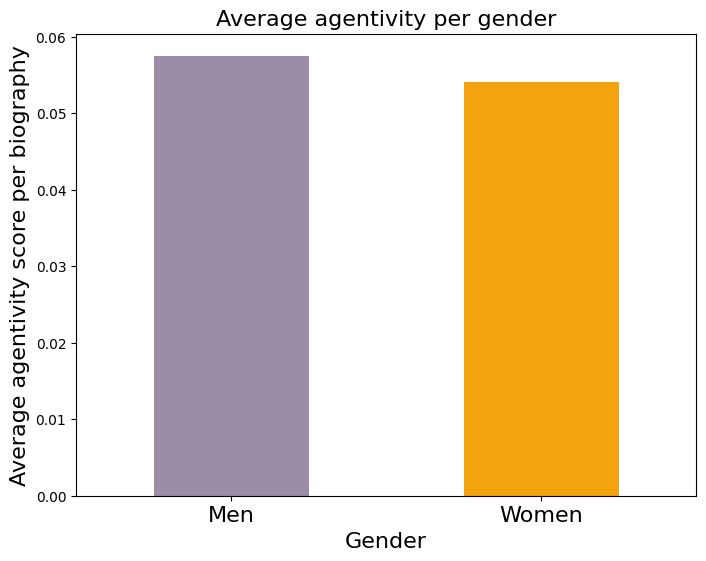

In [15]:
# Printing results

gender_means = df_full.groupby('Gender')['verb_len_ratio'].mean()

plt.figure(figsize=(8, 6))

gender_means.plot(kind='bar', color=["#9b8da8", "#F3A310"])

plt.title('Average agentivity per gender', fontsize=16)
plt.xlabel('Gender', fontsize=16)
plt.ylabel('Average agentivity score per biography', fontsize=16)
plt.xticks([0, 1], ['Men', 'Women'], rotation=0, fontsize=16)

Graphics seem to indicate that men are slightly more agentive than women but let's check this thanks to statistical analysis.

### 3.1.3 Statistical analysis

To decide which statistical test should be used, we first need to understand the distribution of the variable gender. To do so, we will use a Shapiro-Wilk test. If the distribution is normal, a T-test will be done, otherwise we'll do a Mann Whitney U-test.

In [16]:
# Testing the distribution

df_stats = df_full.copy()

men = df_stats[df_stats['Gender'] == 'Men']['verb_len_ratio'].dropna()
women = df_stats[df_stats['Gender'] == 'Women']['verb_len_ratio'].dropna()

stat_h, p_norm_h = stats.shapiro(men)
stat_f, p_norm_f = stats.shapiro(women)
print(f"[Normality] Men group : p-value = {p_norm_h:.4f}")
print(f"[Normality] Women group : p-value = {p_norm_f:.4f}")

if p_norm_h < 0.05 or p_norm_f < 0.05:
    print("-> The data are NOT normally distributed. Use the nonparametric test (Mann-Whitney).")
else:
    print("-> The data are normally distributed. Using Student's t-test.")

[Normality] Men group : p-value = 0.0000
[Normality] Women group : p-value = 0.0000
-> The data are NOT normally distributed. Use the nonparametric test (Mann-Whitney).


In [17]:
# Performing Mann-Whitney test

stat_mw, p_mw = stats.mannwhitneyu(men, women, alternative='two-sided')
print(f"\nMann-Whitney results : p-value = {p_mw:.4e}")

if p_mw < 0.05:
    print("-> CONCLUSION: There is a STATISTICALLY SIGNIFICANT difference in agency between men and women (p < 0.05).")
else:
    print("-> CONCLUSION: The difference in agency is not statistically significant.")



Mann-Whitney results : p-value = 1.1738e-08
-> CONCLUSION: There is a STATISTICALLY SIGNIFICANT difference in agency between men and women (p < 0.05).


## 3.2 Analyze per gender per sport category

### 3.2.1 Graphical display

In [18]:
df_full['Sport'] = df_full['Sport_Gender'].str.rsplit('_', n=1).str[0] # creating a column only with the sport of the athlete

In [19]:
# Defining sports categories

dictionnary_of__categories = {
    'Football': 'Historically_male',
    'Rugby': 'Historically_male',
    'Gymnastics': 'Historically_female',
    'Figure_Skating': 'Historically_female'
}

df_full['sport_type'] = df_full['Sport'].map(dictionnary_of__categories)

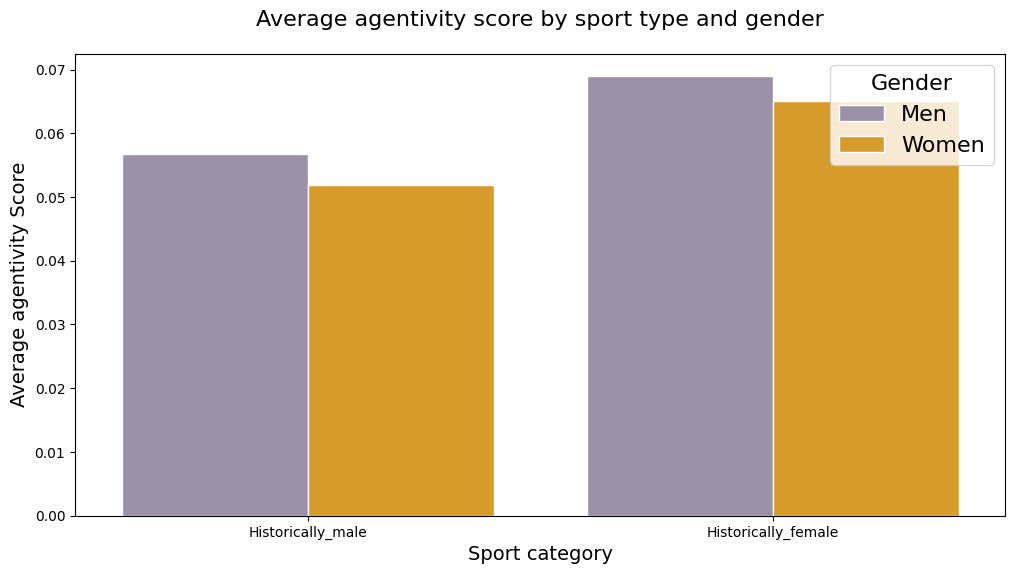

In [40]:
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=df_full, 
    x='sport_type',  
    y='verb_len_ratio', 
    hue='Gender',        
    palette={"Men": "#9b8da8", "Women": "#F3A310"}, 
    errorbar=None,       
    
    edgecolor='white'
)

plt.title('Average agentivity score by sport type and gender', fontsize=16, pad=20)
plt.xlabel('Sport category', fontsize=14)
plt.ylabel('Average agentivity Score', fontsize=14)
plt.legend(title='Gender', title_fontsize='16', fontsize='16')

### 3.2.2 Statistical analysis

Text(0, 0.5, 'Frequency')

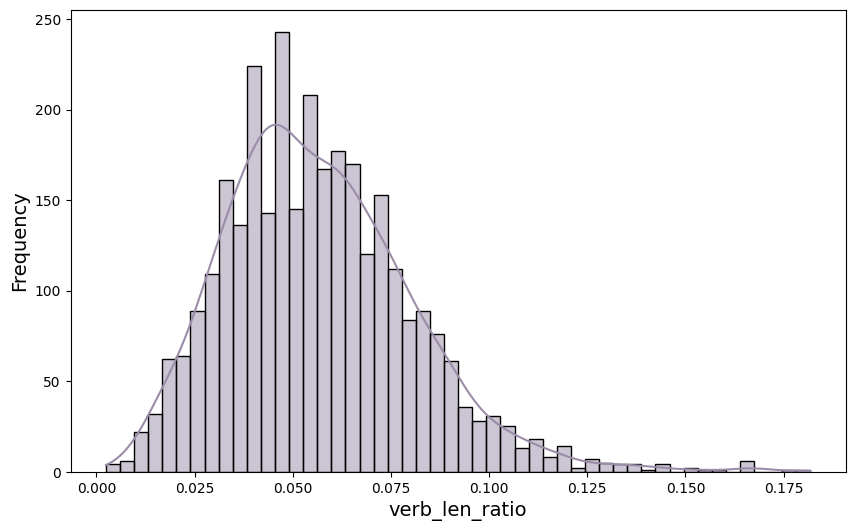

In [ ]:
# Checking distribution of verb_len_ratio

plt.figure(figsize=(10, 6))

# Printing histogramm of the variable
sns.histplot(df_full['verb_len_ratio'], kde=True, color="#9b8da8", bins=50)

plt.xlabel('verb_len_ratio', fontsize=14)
plt.ylabel('Frequency', fontsize=14)

We will use anova test.

In [22]:
# Applying log transformation because verb_len_ratio variable is log distributed (see previous graphic)
df_full['log_verb_len_ratio'] = np.log(df_full['verb_len_ratio'])

# Anova test
model_log = smf.ols('log_verb_len_ratio ~ C(Gender) * C(sport_type)', data=df_full).fit()
anova_log = sm.stats.anova_lm(model_log, typ=2)
print(anova_log)
p_value_interaction = anova_log.loc['C(Gender):C(sport_type)', 'PR(>F)']

# Printing result
if p_value_interaction < 0.05:
    print("Conclusion : The interaction effect IS significant. This provides scientific proof that the gender gap in agency varies depending on the type of sport.")
else:
    print("Conclusion : The interaction effect is NOT significant. The difference in agency between men and women remains the same regardless of the type of sport.")

                             sum_sq      df          F        PR(>F)
C(Gender)                 12.401028     1.0  58.342951  2.923611e-14
C(sport_type)              9.747132     1.0  45.857203  1.518520e-11
C(Gender):C(sport_type)    0.014892     1.0   0.070063  7.912629e-01
Residual                 651.478038  3065.0        NaN           NaN
Conclusion : The interaction effect is NOT significant. The difference in agency between men and women remains the same regardless of the type of sport.


## Conclusion

Our results indicate that there is a small but significant difference of agentivity between men and women in sports. However, there is no significant difference of agentivity between genders accross historically female and historically male sports.

## Annex

Being curious and having all data available, it was decided to replicate the analysis on two other variables : active_count_len_ratio and passive_count-len_ratio. The first variable is a ratio of the number of active verbs by the length of the biography, the second one is the ratio of the number of passive verbs by the length of the biography.

## 1. Active verbs

### 1.1 Analysis per gender

([<matplotlib.axis.XTick at 0x1cf47804290>,
 [Text(0, 0, 'Men'), Text(1, 0, 'Women')])

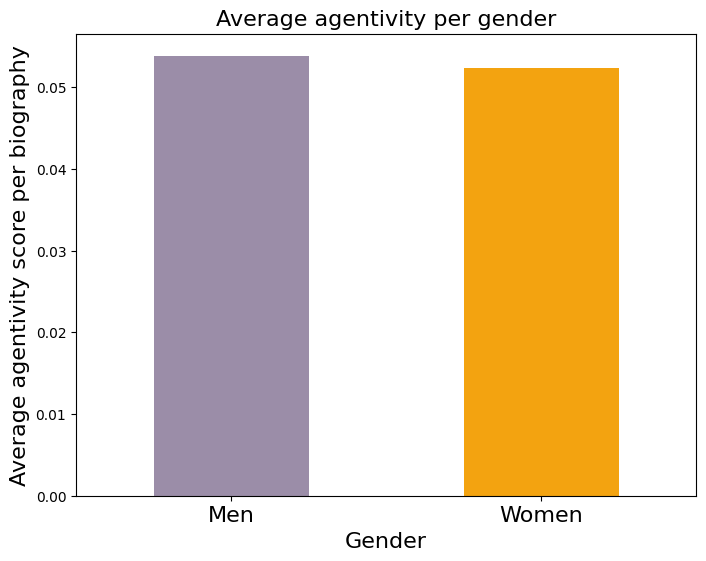

In [23]:
# Printing results

gender_means = df_full.groupby('Gender')['active_count_len_ratio'].mean()

plt.figure(figsize=(8, 6))

gender_means.plot(kind='bar', color=["#9b8da8", "#F3A310"])

plt.title('Average agentivity per gender', fontsize=16)
plt.xlabel('Gender', fontsize=16)
plt.ylabel('Average agentivity score per biography', fontsize=16)
plt.xticks([0, 1], ['Men', 'Women'], rotation=0, fontsize=16)

In [24]:
# Testing the distribution

df_stats = df_full.copy()

men = df_stats[df_stats['Gender'] == 'Men']['active_count_len_ratio'].dropna()
women = df_stats[df_stats['Gender'] == 'Women']['active_count_len_ratio'].dropna()

stat_h, p_norm_h = stats.shapiro(men)
stat_f, p_norm_f = stats.shapiro(women)
print(f"[Normality] Men group : p-value = {p_norm_h:.4f}")
print(f"[Normality] Women group : p-value = {p_norm_f:.4f}")

if p_norm_h < 0.05 or p_norm_f < 0.05:
    print("-> The data are NOT normally distributed. Use the nonparametric test (Mann-Whitney).")
else:
    print("-> The data are normally distributed. Using Student's t-test.")

[Normality] Men group : p-value = 0.0000
[Normality] Women group : p-value = 0.0000
-> The data are NOT normally distributed. Use the nonparametric test (Mann-Whitney).


In [25]:
# Performing Mann-Whitney test

stat_mw, p_mw = stats.mannwhitneyu(men, women, alternative='two-sided')
print(f"\nMann-Whitney results : p-value = {p_mw:.4e}")

if p_mw < 0.05:
    print("-> CONCLUSION: There is a STATISTICALLY SIGNIFICANT difference in agency between men and women (p < 0.05).")
else:
    print("-> CONCLUSION: The difference in agency is not statistically significant.")


Mann-Whitney results : p-value = 4.9763e-05
-> CONCLUSION: There is a STATISTICALLY SIGNIFICANT difference in agency between men and women (p < 0.05).


### 1.2 Analysis per gender and sport category

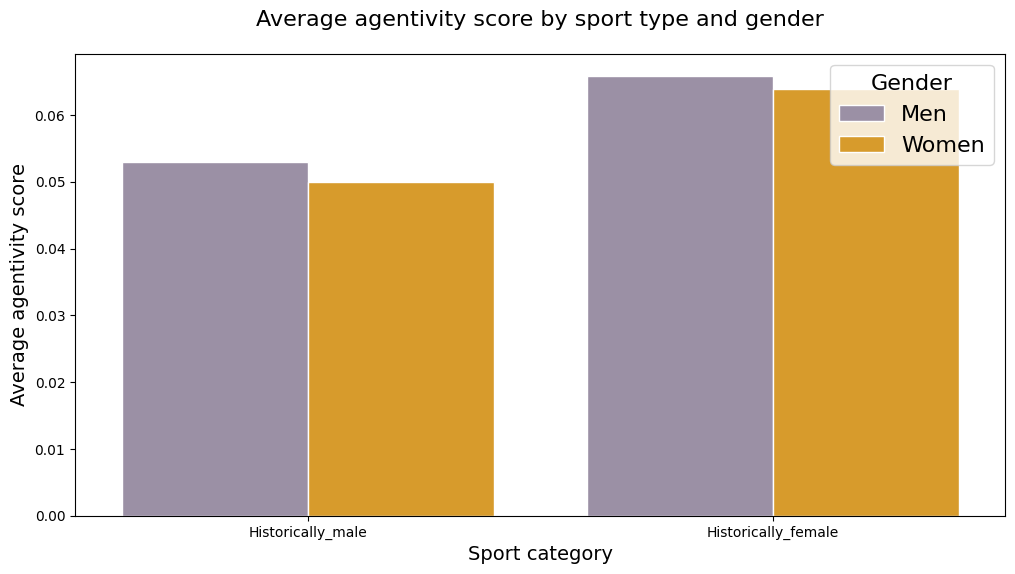

In [39]:
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=df_full, 
    x='sport_type',  
    y='active_count_len_ratio', 
    hue='Gender',      
    palette={"Men": "#9b8da8", "Women": "#F3A310"}, 
    errorbar=None,     
    edgecolor='white'
)

plt.title('Average agentivity score by sport type and gender', fontsize=16, pad=20)
plt.xlabel('Sport category', fontsize=14)
plt.ylabel('Average agentivity score', fontsize=14)
plt.legend(title='Gender', title_fontsize='16', fontsize='16')

Text(0, 0.5, 'Frequency')

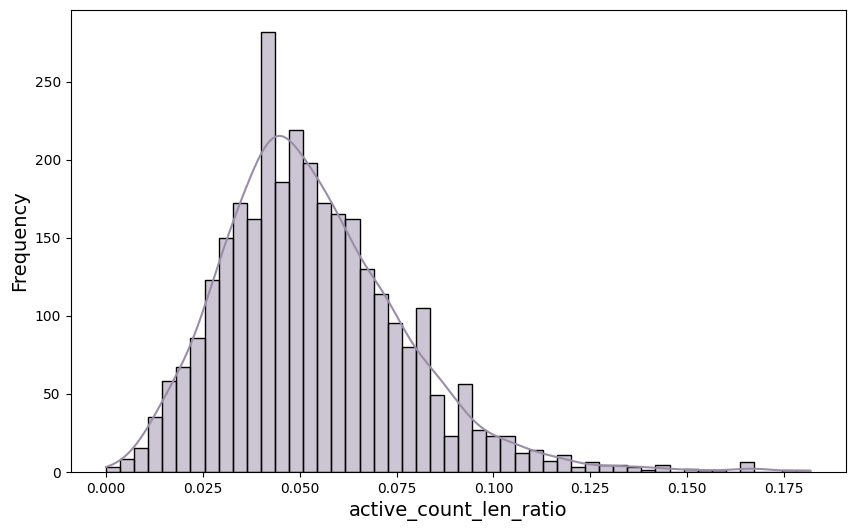

In [27]:
# Checking distribution of active_count_len_ratio

plt.figure(figsize=(10, 6))

# Printing histogramm of the variable
sns.histplot(df_full['active_count_len_ratio'], kde=True, color="#9b8da8", bins=50)

plt.xlabel('active_count_len_ratio', fontsize=14)
plt.ylabel('Frequency', fontsize=14)

In [28]:
# Applying log transformation because active_count_len_ratio variable is log distributed (see previous graphic)
df_full['log_active_count_len_ratio'] = np.log1p(df_full['active_count_len_ratio'])  # this function calculate ln(x+1). It's used to have only positive values otherwise, anova test crashes

# Anova test
model_log = smf.ols('log_active_count_len_ratio ~ C(Gender) * C(sport_type)', data=df_full).fit()
anova_log = sm.stats.anova_lm(model_log, typ=2)
print(anova_log)
p_value_interaction = anova_log.loc['C(Gender):C(sport_type)', 'PR(>F)']

# Printing result
if p_value_interaction < 0.05:
    print("Conclusion : The interaction effect IS significant. This provides scientific proof that the gender gap in agency varies depending on the type of sport.")
else:
    print("Conclusion : The interaction effect is NOT significant. The difference in agency between men and women remains the same regardless of the type of sport.")

                           sum_sq      df          F        PR(>F)
C(Gender)                0.005177     1.0  10.919718  9.624037e-04
C(sport_type)            0.041344     1.0  87.198914  1.829120e-20
C(Gender):C(sport_type)  0.000056     1.0   0.118801  7.303620e-01
Residual                 1.453229  3065.0        NaN           NaN
Conclusion : The interaction effect is NOT significant. The difference in agency between men and women remains the same regardless of the type of sport.


To conclude on this part, the distributions of active verbs only very similar to the distributions of all verbs. Therefore, statistical results are the same: there's a significant difference in terms of agency across gender but there's no significant difference across gender and sport categories.

## 2. Passive verbs

### 2.1 Analysis per gender

([<matplotlib.axis.XTick at 0x1cf46dea250>,
 [Text(0, 0, 'Men'), Text(1, 0, 'Women')])

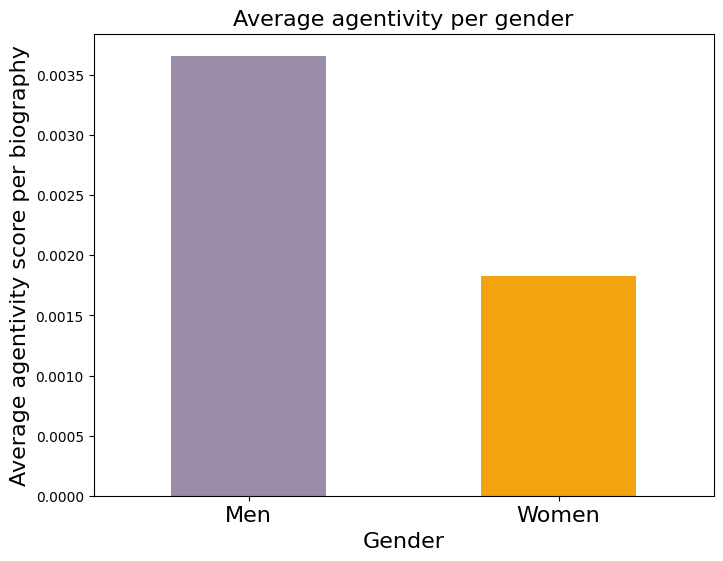

In [29]:
# Printing results

gender_means = df_full.groupby('Gender')['passive_count_len_ratio'].mean()

plt.figure(figsize=(8, 6))

gender_means.plot(kind='bar', color=["#9b8da8", "#F3A310"])

plt.title('Average agentivity per gender', fontsize=16)
plt.xlabel('Gender', fontsize=16)
plt.ylabel('Average agentivity score per biography', fontsize=16)
plt.xticks([0, 1], ['Men', 'Women'], rotation=0, fontsize=16)

In [30]:
# Testing the distribution

df_stats = df_full.copy()

men = df_stats[df_stats['Gender'] == 'Men']['passive_count_len_ratio'].dropna()
women = df_stats[df_stats['Gender'] == 'Women']['passive_count_len_ratio'].dropna()

stat_h, p_norm_h = stats.shapiro(men)
stat_f, p_norm_f = stats.shapiro(women)
print(f"[Normality] Men group : p-value = {p_norm_h:.4f}")
print(f"[Normality] Women group : p-value = {p_norm_f:.4f}")

if p_norm_h < 0.05 or p_norm_f < 0.05:
    print("-> The data are NOT normally distributed. Use the nonparametric test (Mann-Whitney).")
else:
    print("-> The data are normally distributed. Using Student's t-test.")

[Normality] Men group : p-value = 0.0000
[Normality] Women group : p-value = 0.0000
-> The data are NOT normally distributed. Use the nonparametric test (Mann-Whitney).


In [31]:
# Performing Mann-Whitney test

stat_mw, p_mw = stats.mannwhitneyu(men, women, alternative='two-sided')
print(f"\nMann-Whitney results : p-value = {p_mw:.4e}")

if p_mw < 0.05:
    print("-> CONCLUSION: There is a STATISTICALLY SIGNIFICANT difference in agency between men and women (p < 0.05).")
else:
    print("-> CONCLUSION: The difference in agency is not statistically significant.")



Mann-Whitney results : p-value = 6.5253e-14
-> CONCLUSION: There is a STATISTICALLY SIGNIFICANT difference in agency between men and women (p < 0.05).


### 2.2 Analysis per gender and sport category

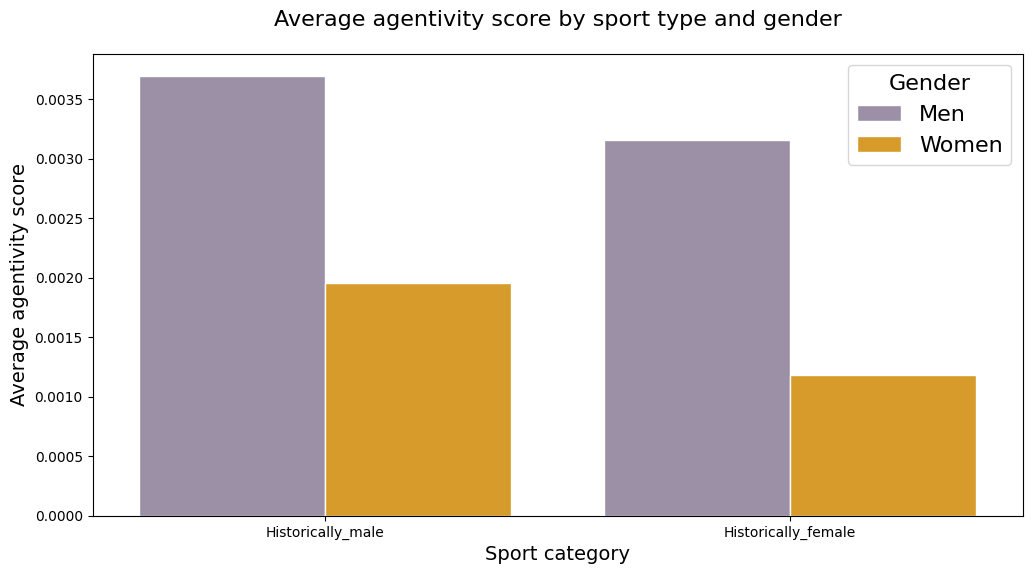

In [41]:
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=df_full, 
    x='sport_type',  
    y='passive_count_len_ratio', 
    hue='Gender',      
    palette={"Men": "#9b8da8", "Women": "#F3A310"}, 
    errorbar=None,     
    edgecolor='white'
)

plt.title('Average agentivity score by sport type and gender', fontsize=16, pad=20)
plt.xlabel('Sport category', fontsize=14)
plt.ylabel('Average agentivity score', fontsize=14)
plt.legend(title='Gender', title_fontsize='16', fontsize='16')

Text(0, 0.5, 'Frequency')

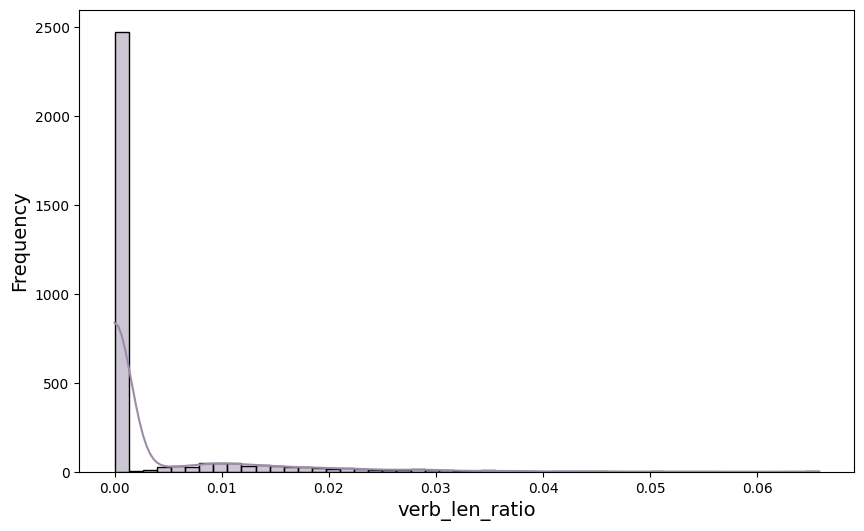

In [ ]:
# Checking distribution of verb_len_ratio

plt.figure(figsize=(10, 6))

# Printing histogramm of the variable
sns.histplot(df_full['passive_count_len_ratio'], kde=True, color="#9b8da8", bins=50)

plt.xlabel('verb_len_ratio', fontsize=14)
plt.ylabel('Frequency', fontsize=14)

In [ ]:
# Applying log transformation because passive_count_len_ratio variable is log distributed (see previous graphic)
df_full['log_passive_count_len_ratio'] = np.log1p(df_full['passive_count_len_ratio'])

# Anova test
model_log = smf.ols('log_passive_count_len_ratio ~ C(Gender) * C(sport_type)', data=df_full).fit()
anova_log = sm.stats.anova_lm(model_log, typ=2)
print(anova_log)
p_value_interaction = anova_log.loc['C(Gender):C(sport_type)', 'PR(>F)']

# Printing result
if p_value_interaction < 0.05:
    print("Conclusion : The interaction effect IS significant. This provides scientific proof that the gender gap in agency varies depending on the type of sport.")
else:
    print("Conclusion : The interaction effect is NOT significant. The difference in agency between men and women remains the same regardless of the type of sport.")

                           sum_sq      df          F        PR(>F)
C(Gender)                0.001942     1.0  33.809940  6.702295e-09
C(sport_type)            0.000112     1.0   1.943895  1.633473e-01
C(Gender):C(sport_type)  0.000003     1.0   0.055934  8.130576e-01
Residual                 0.176046  3065.0        NaN           NaN
Conclusion : The interaction effect is NOT significant. The difference in agency between men and women remains the same regardless of the type of sport.


To conclude on this part, the distributions of passive verbs are very different from the distributions of the sum of all verbs. Indeed, there a much more passive verbs for men than for women. Though, statistical results are the same: there's a significant difference in terms of agency across gender but there's no significant difference across gender and sport categories.

The replication of the results with different types of verbs increases their strength. 